In [2]:
#Import necessary libraries
from scipy.stats import qmc
import numpy as np
import pandas as pd

from scipy.stats import norm
from scipy.optimize import minimize
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern

In [3]:
#Function 5
#Extracting updated data and turning it into a pandas dataframe
data = pd.read_csv('Data/Week 6 - Function 5.csv') 
columns = ['Input 1', 'Input 2', 'Input 3', 'Input 4', 'Outputs']
#Remove columns with NaN values
data = data.dropna(axis = 1)
data.columns = columns
#Add Week 7's data to our pandas dataframe
new_data7 = np.array([0.992528, 0.832966, 0.994330, 0.998665,
                     6089.295977690454])
data.loc[len(data)] = new_data7
data





,Input 1,Input 2,Input 3,Input 4,Outputs
0,0.191447,0.038193,0.607418,0.414584,64.443440
1,0.758653,0.536518,0.656000,0.360342,18.301380
2,0.438350,0.804340,0.210245,0.151295,0.112940
3,0.706051,0.534192,0.264243,0.482088,4.210898
4,0.836478,0.193610,0.663893,0.785649,258.370500
5,0.683432,0.118663,0.829046,0.567577,78.434390
6,0.553621,0.667350,0.323806,0.814870,57.571540
7,0.352356,0.322242,0.116979,0.473113,109.571900
8,0.153786,0.729382,0.422598,0.443074,8.847992
9,0.463442,0.630025,0.107906,0.957644,233.223600


In [4]:
#Extract the Data Into Numpy Arrays
X = np.array(data[['Input 1', 'Input 2', 'Input 3', 'Input 4']])
Y = np.array(data[['Outputs']])



In [5]:
# Find the pearson correlations matrix
data.corr(method = 'pearson')

,Input 1,Input 2,Input 3,Input 4,Outputs
Input 1,1.000000,0.103197,0.140497,0.262854,0.579774
Input 2,0.103197,1.000000,0.285089,0.487782,0.533270
Input 3,0.140497,0.285089,1.000000,0.290567,0.611282
Input 4,0.262854,0.487782,0.290567,1.000000,0.556046
Outputs,0.579774,0.533270,0.611282,0.556046,1.000000


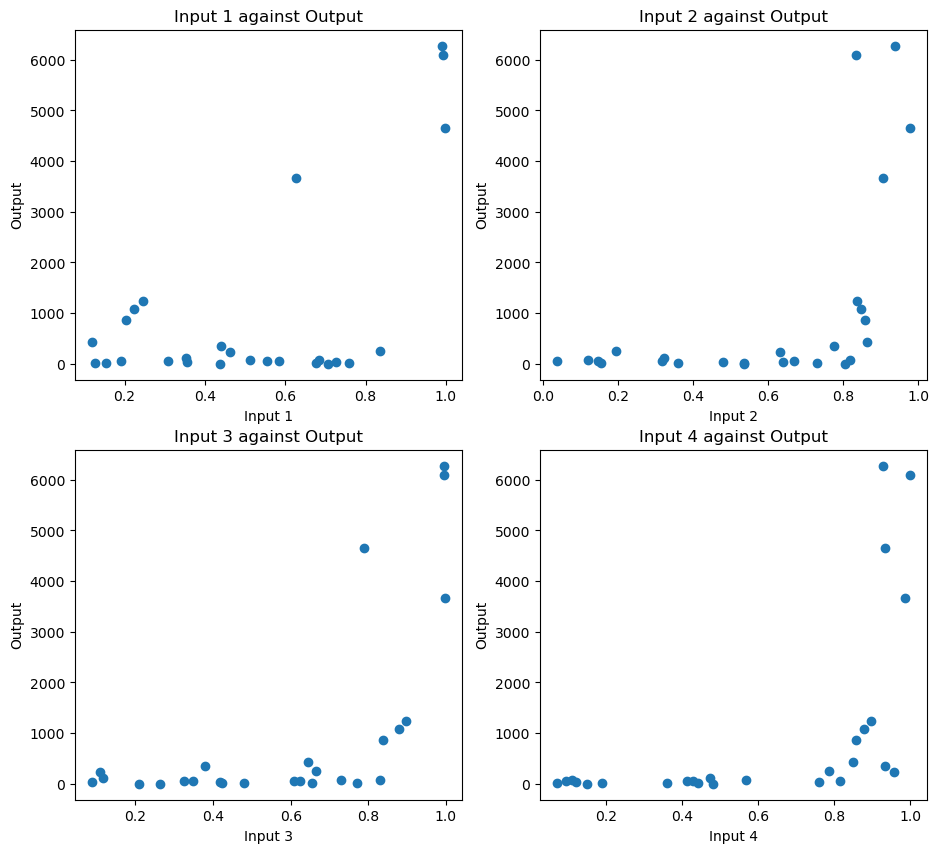

In [6]:
#Plotting each Input against the output
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2,2, figsize = (11,10))

ax[0][0].scatter(X[:,0], Y)
ax[0][1].scatter(X[:,1], Y)
ax[1][0].scatter(X[:,2], Y)
ax[1][1].scatter(X[:,3], Y)

#Creating titles and axis labels
ax[0][0].set_title('Input 1 against Output')
ax[0][1].set_title('Input 2 against Output')
ax[1][0].set_title('Input 3 against Output')
ax[1][1].set_title('Input 4 against Output')

ax[0][0].set_xlabel('Input 1')
ax[0][0].set_ylabel('Output')

ax[0][1].set_xlabel('Input 2')
ax[0][1].set_ylabel('Output')

ax[1][0].set_xlabel('Input 3')
ax[1][0].set_ylabel('Output')

ax[1][1].set_xlabel('Input 4')
ax[1][1].set_ylabel('Output')

plt.show()

In [7]:
#We now use random forest regression to generate a list of promising points for a GP
#to evaluate
from sklearn.ensemble import RandomForestRegressor
#Using randomized search CV for light hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 5],
    "max_features": [0.5, 0.7, 1.0]
}

rf = RandomForestRegressor(
    n_jobs=-1,
    random_state=42
)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1, random_state = 42)

search.fit(X, Y.ravel())

rf_best = search.best_estimator_
print("Tuned RF Model:", rf_best)


Tuned RF Model: RandomForestRegressor(max_features=0.5, n_estimators=200, n_jobs=-1,
                      random_state=42)


In [8]:
#Use latin hypercube sampling to create a grid 
d = 4
n = 40000
sampler = qmc.LatinHypercube(d, seed = 42)
grid = sampler.random(n)   # samples in [0,1]^d

#Use random forest model to outputs from the grid
Y_pred = rf_best.predict(grid)

#Select the top 200 points
n_select = 200
top_idx = np.argsort(Y_pred)[-n_select:]
X_candidates = grid[top_idx]

In [9]:
#We now set the Kernel to be the Matern Kernel
nu = 2.5
kernel = Matern(length_scale=1.0, length_scale_bounds= (1e-2,1e1), nu = nu)
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-10,
    normalize_y = True)

gp.fit(X,Y)



#fit GP to candidate points suggested by Random Forest model
mu, std = gp.predict(X_candidates, return_std = True)

#fit GP to candidate points generated over the entire domain
mu_grid, std_grid = gp.predict(grid, return_std = True)

In [10]:
#Calculate UCB 
beta = 1.96 #set exploration parameter
UCB = mu + beta*std 
UCB_grid = mu_grid + beta*std_grid 
#Find point selected by random forest model that maximizes UCB
X_next = X_candidates[np.argmax(UCB)]
#Find point in the entire domain that maximizes UCB
X_next_grid = grid[np.argmax(UCB_grid)]
print("Random Forest Hybrid model next suggested point:", np.round(X_next,6))
print("GP model next suggested point:", np.round(X_next_grid,6))

Random Forest Hybrid model next suggested point: [0.970115 0.990124 0.944969 0.988218]
GP model next suggested point: [0.970115 0.990124 0.944969 0.988218]
